# Project One: Supervised Learning on Structured Tabular Data

Dataset: California Housing dataset

### Project Objective

The objective of this project is to develop and evaluate supervised regression models using structured tabular data to predict median house values in California districts.

This is a regression task, where the target variable is continuous.

### Libraries Used

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Dataset Loading

The dataset is loaded into a Pandas DataFrame from a CSV file.

In [3]:
data = pd.read_csv("../dataset/california_housing.csv")

### Exploratory Data Analysis

##### Preview Data

The commands below does the following:
- Inspect first few rows
- View column names
- Check data types and null values
- Generate statistical summaries

In [4]:
data.head(), data.columns, data.info(), data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              20640 non-null  float64
 1   HouseAge            20640 non-null  float64
 2   AveRooms            20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   AveOccup            20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


(   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 
    Longitude  median_house_value  
 0    -122.23               4.526  
 1    -122.22               3.585  
 2    -122.24               3.521  
 3    -122.25               3.413  
 4    -122.25               3.422  ,
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
        'Latitude', 'Longitude', 'median_house_value'],
       dtype='object'),
 None,
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
 count  20640.000000  20640.000000  20640.000000  20640.000000  20640.0

##### Distribution Analysis

- Visualizes feature distributions.
- Helps identify skewness and outliers.

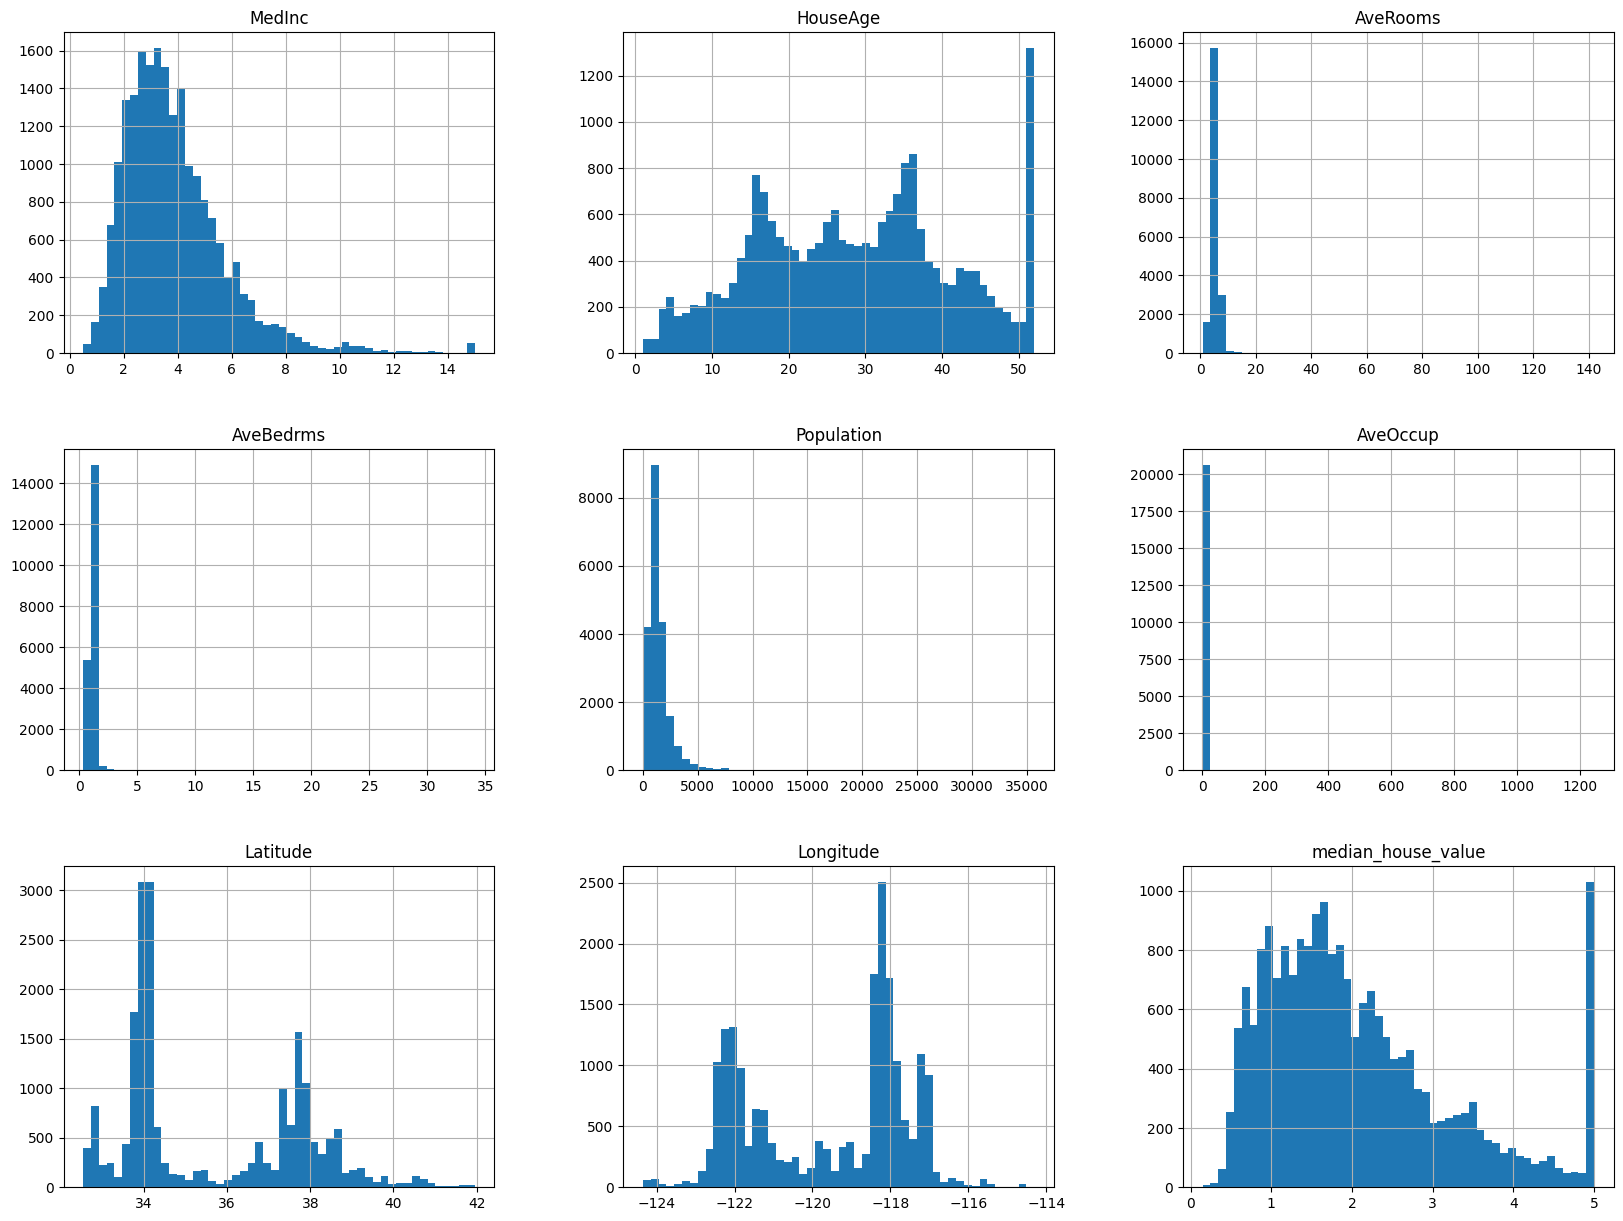

In [5]:
data.hist(bins=50, figsize=(20, 15))
plt.show()

#### Geographic Visualization
- Displays geographic housing distribution.

<Axes: xlabel='Longitude', ylabel='Latitude'>

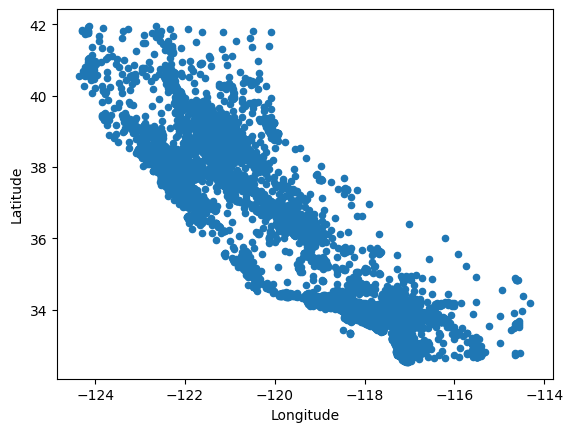

In [6]:
data.plot(kind="scatter", x="Longitude", y="Latitude")

#### Scatter Plot

This plot visualizes:
- Geographic location
- Population density (point size)
- Median house value (color intensity)

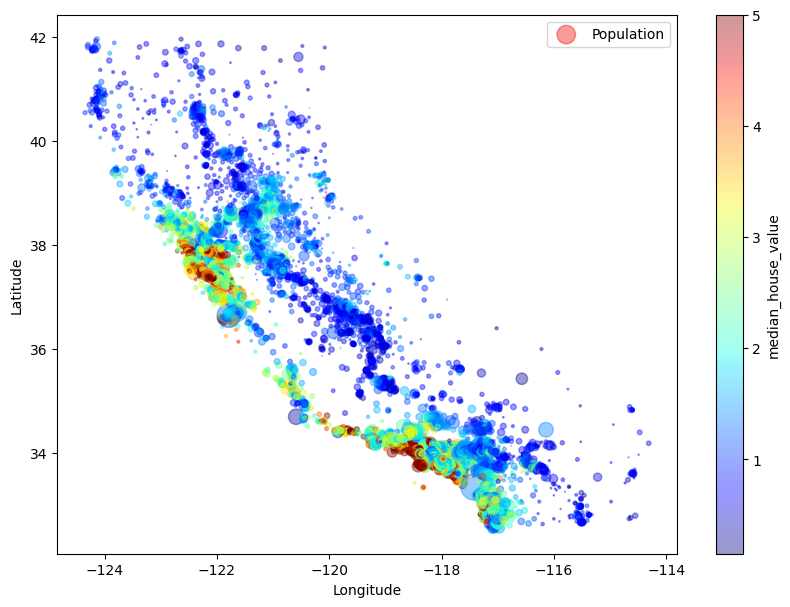

In [7]:
data.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.4,
             s=(data["Population"]).astype(float)/100, label="Population", figsize=(10,7),
             c='median_house_value', cmap=plt.get_cmap("jet"), colorbar=True)

plt.legend()

#### Correlation Matrix

- Computes Pearson correlation between features.
- Helps identify strong predictors of house value.

<Axes: >

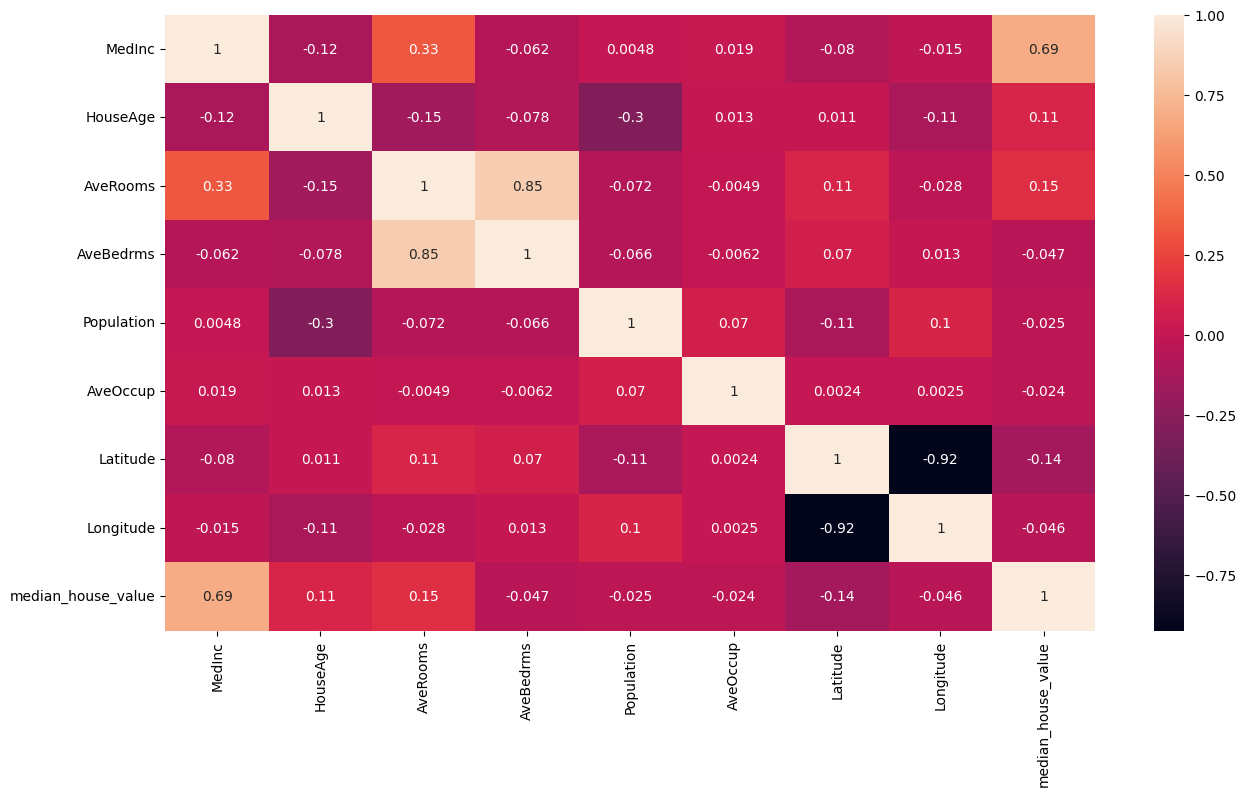

In [8]:
plt.figure(figsize=(15, 8))
sns.heatmap(data.corr(), annot=True)

### Feature Engineering

#### Target Variable
- y contains the target.

In [9]:
y = data["median_house_value"]
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: median_house_value, dtype: float64

#### Feature Matrix

+ X contains all predictors.


In [10]:
X = data.drop(columns="median_house_value")
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Model Initialization

#### Linear Regression

- Assumes linear relationship.

In [12]:
lin_reg = LinearRegression()


#### Decision Tree Regressor

- Captures nonlinear relationships.

In [13]:
tree = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=5,
    random_state=42
)


#### Random Forest Regressor

- Ensemble of 300 decision trees.

In [14]:

forest = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

### Model Training

In [15]:
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [17]:
forest.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Prediction

In [18]:
lin_reg_y_pred = lin_reg.predict(X_test)
tree_y_pred = tree.predict(X_test)
forest_y_pred = forest.predict(X_test)

### Model Evaluation

Metrics used:

Mean Squared Error (MSE)
$$MSE = \frac{1}{n}∑(y−\hat{y})^2$$

- Penalizes large errors heavily.

Mean Absolute Error (MAE)

$$MAE = \frac{1}{n}∑|y−\hat{y}|$$

- More robust to outliers than MSE.

R² Score

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$


- Measures explained variance.
- 1 → perfect model
- 0 → no better than mean prediction

Where:

- $y_i$ = actual value  
- $\hat{y}_i$ = predicted value  
- $\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$ = mean of actual values




In [19]:
lin_reg_mse = mean_squared_error(y_test, lin_reg_y_pred)
lin_reg_mae = mean_absolute_error(y_test, lin_reg_y_pred)
lin_reg_r2 = r2_score(y_test, lin_reg_y_pred)


tree_mse = mean_squared_error(y_test, tree_y_pred)
tree_mae = mean_absolute_error(y_test, tree_y_pred)
tree_r2 = r2_score(y_test, tree_y_pred)


forest_mse = mean_squared_error(y_test, forest_y_pred)
forest_mae = mean_absolute_error(y_test, forest_y_pred)
forest_r2 = r2_score(y_test, forest_y_pred)

### Linear Regression Metrics

In [20]:
print("MSE (mean squared error):", lin_reg_mse)
print("MAE (mean absolute error):", lin_reg_mae)
print("R² (coefficient of determination):", lin_reg_r2)

MSE (mean squared error): 0.5558915986952437
MAE (mean absolute error): 0.533200130495656
R² (coefficient of determination): 0.5757877060324512


### Decision Tree Regressor Metrics

In [21]:
print("MSE (mean squared error):", tree_mse)
print("MAE (mean absolute error):", tree_mae)
print("R² (coefficient of determination):", tree_r2)

MSE (mean squared error): 0.3980822879937136
MAE (mean absolute error): 0.41534420141423944
R² (coefficient of determination): 0.6962152315774717


### Random Forest Regressor Metrics

In [22]:
print("MSE (mean squared error):", forest_mse)
print("MAE (mean absolute error):", forest_mae)
print("R² (coefficient of determination):", forest_r2)

MSE (mean squared error): 0.2476779606034368
MAE (mean absolute error): 0.3302012807835189
R² (coefficient of determination): 0.8109918622994166


### Prediction Graph

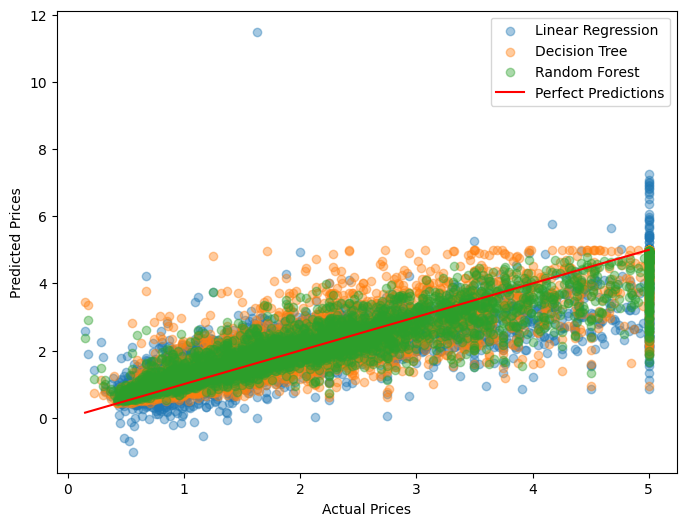

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lin_reg_y_pred , alpha=0.4, label="Linear Regression")
plt.scatter(y_test, tree_y_pred, alpha=0.4, label="Decision Tree")
plt.scatter(y_test, forest_y_pred, alpha=0.4, label="Random Forest")

min_val = min(y_test)
max_val = max(y_test)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="-", color="red", label="Perfect Predictions")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.legend()

plt.show()

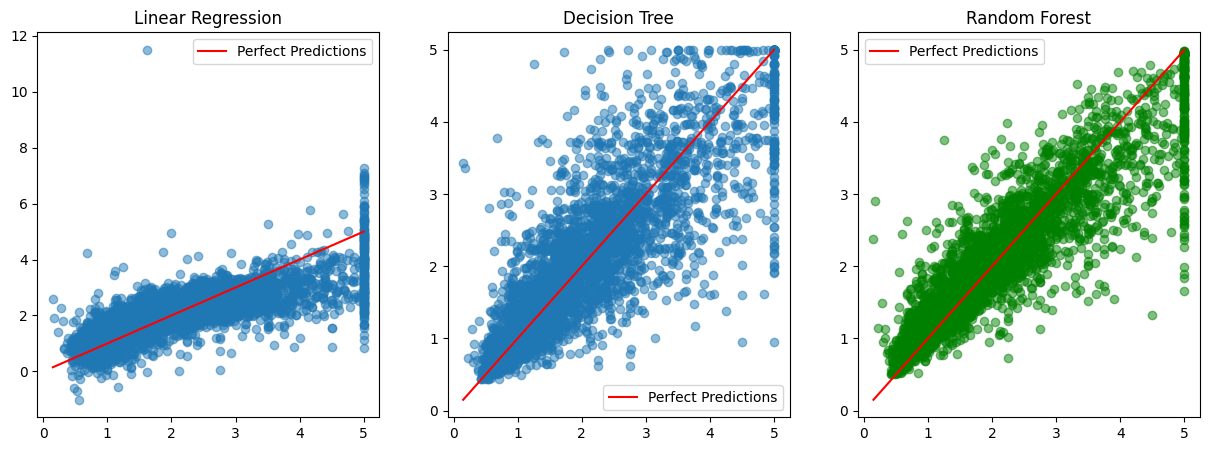

In [31]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].scatter(y_test, lin_reg_y_pred , alpha=0.5)
ax[0].set_title("Linear Regression")
ax[0].plot([min_val, max_val], [min_val, max_val], linestyle="-", color="red", label="Perfect Predictions")
ax[0].legend()

ax[1].scatter(y_test, tree_y_pred, alpha=0.5)
ax[1].set_title("Decision Tree")
ax[1].plot([min_val, max_val], [min_val, max_val], linestyle="-", color="red", label="Perfect Predictions")
ax[1].legend()

ax[2].scatter(y_test, forest_y_pred, alpha=0.5,  color="green")
ax[2].set_title("Random Forest")
ax[2].plot([min_val, max_val], [min_val, max_val], linestyle="-", color="red", label="Perfect Predictions")
ax[2].legend()

plt.show()

### Conclusion

Random Forest performs best, it has the highest R².

Decision Tree sits in between Linear regression and Random Forest

Linear regression struggles with nonlinearities.